# QTEMP v1.0.0 candidate — standardized scientific review

**Status:** candidate only; G9 pending; G10/publication freeze blocked.

QTEMP measures two observable decoded-stream manifestations on native channels: (1) bracketed near-zero or constant-low-information runs with active bilateral context, and (2) near-exact consecutive decoded-waveform repetition. It does **not** identify packet loss, transport failure, buffering, or a unique causal mechanism. The splice detector is excluded after failed analytical validation. No QTEMP scalar is constructed.

This notebook is a non-overwriting reviewed layer. The historical `FINALIZATION_SOURCE` remains the intended v0.3.1 workflow and `FINALIZATION_EXECUTED_REVIEW` remains its evidence record; discrepancies are reported, never silently reconciled.


## 0. Scope, decisions, and non-negotiable freeze boundary


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def resolve_project_root():
    candidates = []
    configured = os.environ.get("QTEMP_PROJECT_ROOT", "").strip()
    if configured:
        candidates.append(Path(configured))
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    candidates.append(
        Path.home()
        / "Desktop"
        / "Nevena_project"
        / "Paper_1"
        / "paper_1"
    )
    checked = []
    for candidate in candidates:
        candidate = candidate.expanduser().resolve()
        if candidate in checked:
            continue
        checked.append(candidate)
        if (
            (candidate / "src" / "paper1_qc" / "qtemp.py").is_file()
            and (
                candidate
                / "src reviewed"
                / "paper1_qc_reviewed"
                / "qtemp_v100_candidate.py"
            ).is_file()
        ):
            return candidate
    raise RuntimeError(
        "QTEMP project root could not be located. Checked: "
        + " | ".join(str(path) for path in checked)
    )

ROOT = resolve_project_root()
for source_path in [ROOT / "src", ROOT / "src reviewed"]:
    source_text = str(source_path)
    if source_text not in sys.path:
        sys.path.insert(0, source_text)
from paper1_qc_reviewed import qtemp_v100_candidate as qtemp

VERSION = qtemp.MEASUREMENT_VERSION
OUTPUT = ROOT / "outputs reviewed" / "QTEMP" / VERSION
for part in ["tables", "validation", "figures", "gallery", "manifests"]:
    (OUTPUT / part).mkdir(parents=True, exist_ok=True)

PUBLICATION_FREEZE = False
G9_COMPLETE = False
assert not PUBLICATION_FREEZE and not G9_COMPLETE
print("QTEMP project root:", ROOT)
print("QTEMP implementation:", Path(qtemp.__file__).resolve())
print("QTEMP output directory:", OUTPUT)

decisions = pd.DataFrame([
    ["qtemp_dropout_duration_fraction", "CANDIDATE_RETAIN_PENDING_G9", "primary duration burden"],
    ["qtemp_dropout_event_rate_per_min", "CANDIDATE_RETAIN_PENDING_G9", "secondary same-ledger frequency view"],
    ["qtemp_frozen_audio_duration_fraction", "CANDIDATE_RETAIN_ZERO_VARIATION_PENDING_G9", "primary rare-event burden; >=40-ms truth scope at supported lags"],
    ["qtemp_frozen_audio_event_rate_per_min", "CANDIDATE_RETAIN_ZERO_VARIATION_PENDING_G9", "secondary same-ledger frequency view"],
    ["qtemp_splice_discontinuity_rate_per_min", "DROP_FAILED_ANALYTICAL_VALIDATION", "held-out recovery failed; 318/519 implausible positives; sample-rate dependence"],
], columns=["feature", "decision", "basis"])
decisions.to_csv(OUTPUT / "tables" / "qtemp_v100_feature_decisions.csv", index=False)
decisions


QTEMP project root: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1
QTEMP implementation: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\src reviewed\paper1_qc_reviewed\qtemp_v100_candidate.py
QTEMP output directory: C:\Users\musikicn\Desktop\Nevena_project\Paper_1\paper_1\outputs reviewed\QTEMP\qtemp-v1.0.0-candidate-g9-pending


,feature,decision,basis
0,qtemp_dropout_duration_fraction,CANDIDATE_RETAIN_PENDING_G9,primary duration burden
1,qtemp_dropout_event_rate_per_min,CANDIDATE_RETAIN_PENDING_G9,secondary same-ledger frequency view
2,qtemp_frozen_audio_duration_fraction,CANDIDATE_RETAIN_ZERO_VARIATION_PENDING_G9,primary rare-event burden; >=40-ms truth scope...
3,qtemp_frozen_audio_event_rate_per_min,CANDIDATE_RETAIN_ZERO_VARIATION_PENDING_G9,secondary same-ledger frequency view
4,qtemp_splice_discontinuity_rate_per_min,DROP_FAILED_ANALYTICAL_VALIDATION,held-out recovery failed; 318/519 implausible ...


## 1. Frozen native-input and provenance contract


In [2]:
input_contract = pd.DataFrame([
    ["waveform", "native decoded channels", "before resampling, mono conversion, normalization, filtering, interpolation, denoising, or re-encoding"],
    ["time region", "frozen task interval", "100-ms symmetric interval edge guard; original time coordinates"],
    ["channel", "independent detection", "temporally coincident accepted channel events collapse by union"],
    ["minimum exposure", "1.0 s", "unavailable below support; never zero-imputed"],
    ["segmentation", "frozen input", "assumed valid; identity/version/hash still required"],
], columns=["item", "required", "interpretation"])
input_contract.to_csv(OUTPUT / "tables" / "qtemp_v100_input_contract.csv", index=False)
input_contract


,item,required,interpretation
0,waveform,native decoded channels,"before resampling, mono conversion, normalizat..."
1,time region,frozen task interval,100-ms symmetric interval edge guard; original...
2,channel,independent detection,temporally coincident accepted channel events ...
3,minimum exposure,1.0 s,unavailable below support; never zero-imputed
4,segmentation,frozen input,assumed valid; identity/version/hash still req...


## 2. Four-feature registry, estimands, support, and event contract


In [3]:
registry = qtemp.feature_registry_frame()
assert tuple(registry.name) == qtemp.ANALYSIS_FEATURES
assert not registry.name.str.contains("splice").any()
registry.to_csv(OUTPUT / "tables" / "qtemp_v100_feature_registry.csv", index=False)
registry[["name", "role", "unit", "formula", "minimum_support", "claim_boundary"]]


,name,role,unit,formula,minimum_support,claim_boundary
0,qtemp_dropout_duration_fraction,candidate primary,fraction,sum accepted recording-level dropout durations...,successful native decode/provenance and >=1 s ...,observable dropout-like gaps; not packet-loss ...
1,qtemp_dropout_event_rate_per_min,secondary same-ledger event-frequency view,events/min,accepted recording-level dropout event count *...,successful native decode/provenance and >=1 s ...,same-ledger event-frequency view; not independ...
2,qtemp_frozen_audio_duration_fraction,provisional primary,fraction,union duration of accepted recording-level dup...,"successful native decode/provenance, non-silen...",near-exact consecutive decoded-waveform repeti...
3,qtemp_frozen_audio_event_rate_per_min,secondary same-ledger event-frequency view,events/min,accepted recording-level duplicated event coun...,"successful native decode/provenance, non-silen...",near-exact consecutive decoded-waveform repeti...


## 3. Numerical, status, channel, and ledger correctness


In [4]:
FS = 16000
def carrier(fs=FS, duration=6.0):
    t = np.arange(round(fs*duration))/fs
    env = .75 + .2*np.sin(2*np.pi*.73*t)
    return .05*env*(np.sin(2*np.pi*173*t+.1)+.45*np.sin(2*np.pi*421*t+.7)+.18*np.sin(2*np.pi*911*t+1.2))

clean = qtemp.extract_qtemp(carrier(), FS, logical_recording_id="clean")
missing = qtemp.extract_qtemp(carrier(), FS, native_source_confirmed=False, logical_recording_id="missing")
injected = qtemp.inject_dropout(carrier(), FS, 2.0, 40.0, mode="zero")
measured = qtemp.extract_qtemp(injected, FS, enabled_event_types=("dropout",), logical_recording_id="dropout")
rebuilt = qtemp.reconstruct_recording_features(measured.event_ledger, measured.recording["qtemp_eligible_duration_sec"])
checks = pd.DataFrame([
    ["exactly four exported features", len(qtemp.ANALYSIS_FEATURES)==4],
    ["valid absence is measured zero", all(clean.recording[x]==0 for x in qtemp.ANALYSIS_FEATURES)],
    ["unavailable remains missing", all(np.isnan(missing.recording[x]) for x in qtemp.ANALYSIS_FEATURES)],
    ["ledger reconstruction exact", all(np.isclose(rebuilt[x], measured.recording[x], atol=1e-15, rtol=0) for x in qtemp.ANALYSIS_FEATURES)],
    ["splice cannot enter candidate export", not any("splice" in x for x in measured.recording)],
    ["publication freeze disabled", not PUBLICATION_FREEZE],
], columns=["check", "passed"])
checks.to_csv(OUTPUT / "validation" / "qtemp_v100_numerical_checks.csv", index=False)
checks


,check,passed
0,exactly four exported features,True
1,valid absence is measured zero,True
2,unavailable remains missing,True
3,ledger reconstruction exact,True
4,splice cannot enter candidate export,True
5,publication freeze disabled,True


## 4. Panels A–B: target response and discriminant specificity


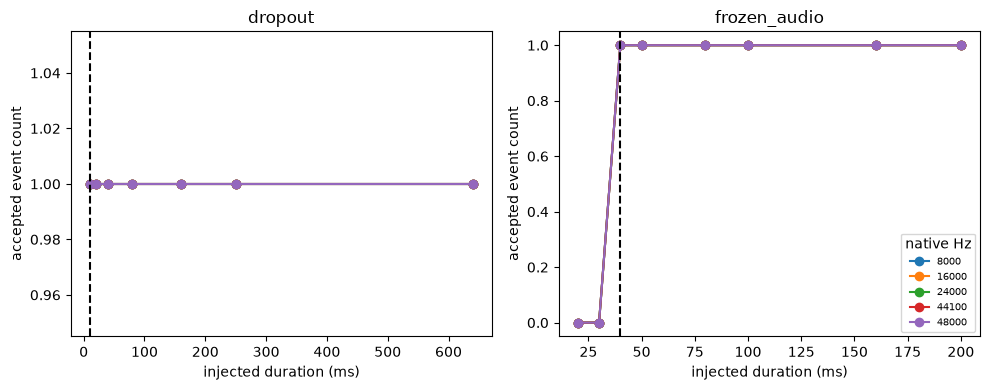

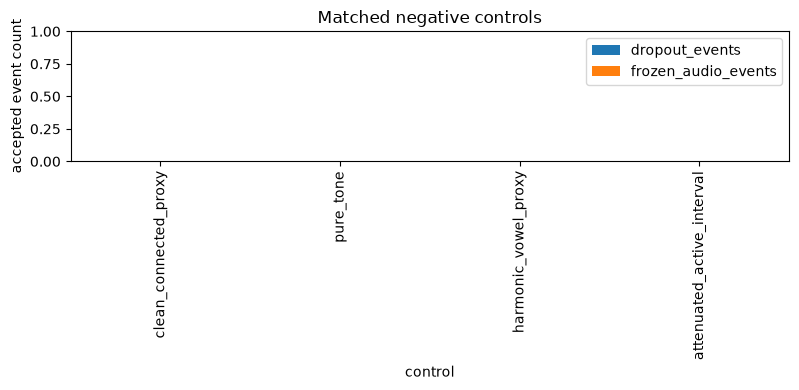

In [5]:
rows=[]
for fs in [8000,16000,24000,44100,48000]:
    for duration in [10,20,40,80,160,250,640]:
        x=carrier(fs)
        y=qtemp.inject_dropout(x,fs,2.0,duration,mode="zero")
        r=qtemp.extract_qtemp(y,fs,enabled_event_types=("dropout",))
        rows.append(["dropout",fs,duration,r.recording["qtemp_dropout_duration_fraction"],r.recording["qtemp_dropout_accepted_event_count"]])
    for duration in [20,30,40,50,80,100,160,200]:
        x=carrier(fs)
        y=qtemp.inject_consecutive_duplicate(x,fs,2.0,duration)
        r=qtemp.extract_qtemp(y,fs,enabled_event_types=("frozen_audio",))
        rows.append(["frozen_audio",fs,duration,r.recording["qtemp_frozen_audio_duration_fraction"],r.recording["qtemp_frozen_audio_accepted_event_count"]])
panel_a=pd.DataFrame(rows,columns=["event_type","sample_rate_hz","dose_ms","duration_fraction","event_count"])
panel_a.to_csv(OUTPUT/"tables"/"qtemp_v100_panel-A_construct-response.source.csv",index=False)
fig,axes=plt.subplots(1,2,figsize=(10,4))
for kind,ax in zip(["dropout","frozen_audio"],axes):
    local=panel_a.query("event_type == @kind")
    for fs,g in local.groupby("sample_rate_hz"):
        ax.plot(g.dose_ms,g.event_count,marker="o",label=str(fs))
    ax.axvline(10 if kind=="dropout" else 40,color="black",ls="--")
    ax.set(title=kind,xlabel="injected duration (ms)",ylabel="accepted event count")
axes[1].legend(title="native Hz",fontsize=7)
fig.tight_layout(); fig.savefig(OUTPUT/"figures"/"qtemp_v100_panel-A_construct-response.png",dpi=300); fig.savefig(OUTPUT/"figures"/"qtemp_v100_panel-A_construct-response.svg"); plt.show()

controls=[]
base=carrier()
t=np.arange(len(base))/FS
control_signals={
 "clean_connected_proxy":base,
 "pure_tone":.05*np.sin(2*np.pi*120*t),
 "harmonic_vowel_proxy":.05*sum(np.sin(2*np.pi*100*h*t)/h for h in range(1,8)),
 "attenuated_active_interval":qtemp.inject_dropout(base,FS,2.0,40,mode="attenuated",attenuation_db=-12),
}
for label,x in control_signals.items():
    r=qtemp.extract_qtemp(x,FS)
    controls.append([label,r.recording["qtemp_dropout_accepted_event_count"],r.recording["qtemp_frozen_audio_accepted_event_count"]])
panel_b=pd.DataFrame(controls,columns=["control","dropout_events","frozen_audio_events"])
panel_b.to_csv(OUTPUT/"tables"/"qtemp_v100_panel-B_discriminant-specificity.source.csv",index=False)
ax=panel_b.set_index("control")[["dropout_events","frozen_audio_events"]].plot.bar(figsize=(8,4),ylim=(0,1))
ax.set(ylabel="accepted event count",title="Matched negative controls"); plt.tight_layout(); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-B_discriminant-specificity.png",dpi=300); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-B_discriminant-specificity.svg"); plt.show()


## 5. Panels C–E: transformation, support, and parameter/merge sensitivity


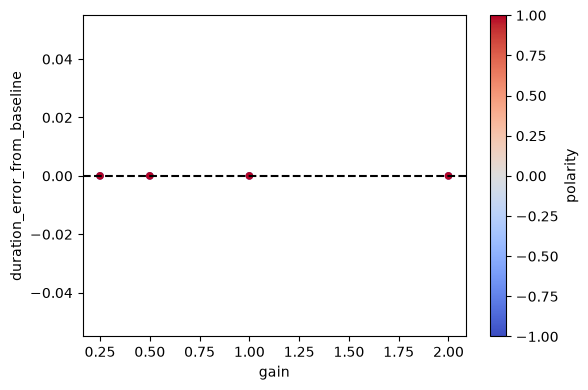

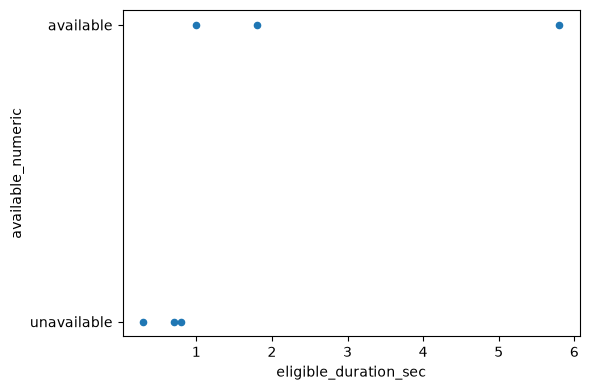

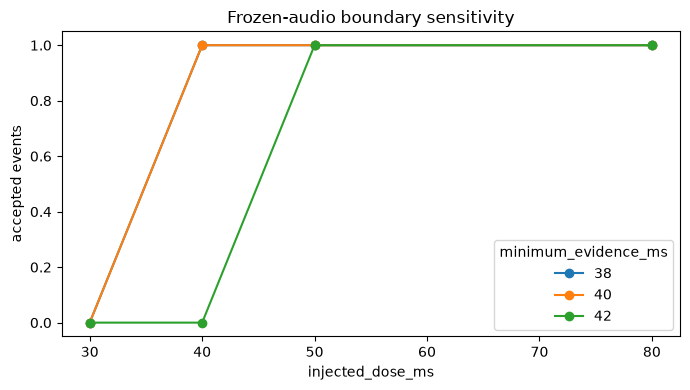

In [6]:
base=qtemp.inject_dropout(carrier(),FS,2.0,40,mode="zero")
rows=[]
for gain in [.25,.5,1,2]:
 for polarity in [-1,1]:
  r=qtemp.extract_qtemp(gain*polarity*base,FS,enabled_event_types=("dropout",))
  rows.append([gain,polarity,r.recording["qtemp_dropout_duration_fraction"],r.recording["qtemp_dropout_event_rate_per_min"]])
panel_c=pd.DataFrame(rows,columns=["gain","polarity","duration_fraction","event_rate_per_min"])
panel_c["duration_error_from_baseline"]=panel_c.duration_fraction-panel_c.query("gain==1 and polarity==1").duration_fraction.iloc[0]
panel_c.to_csv(OUTPUT/"tables"/"qtemp_v100_panel-C_transformation.source.csv",index=False)
ax=panel_c.plot.scatter(x="gain",y="duration_error_from_baseline",c="polarity",colormap="coolwarm",figsize=(6,4)); ax.axhline(0,color="black",ls="--"); plt.tight_layout(); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-C_transformation.png",dpi=300); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-C_transformation.svg"); plt.show()

rows=[]
for duration in [.5,.9,1.0,1.2,2,6]:
 r=qtemp.extract_qtemp(carrier(duration=duration),FS)
 rows.append([duration,r.recording["qtemp_eligible_duration_sec"],r.recording["qtemp_status"],np.isfinite(r.recording[qtemp.ANALYSIS_FEATURES[0]])])
panel_d=pd.DataFrame(rows,columns=["native_duration_sec","eligible_duration_sec","status","available"])
panel_d["available_numeric"]=panel_d["available"].astype(int)
panel_d.to_csv(OUTPUT/"tables"/"qtemp_v100_panel-D_support-availability.source.csv",index=False)
ax=panel_d.plot.scatter(x="eligible_duration_sec",y="available_numeric",figsize=(6,4)); ax.set_yticks([0,1]); ax.set_yticklabels(["unavailable","available"]); plt.tight_layout(); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-D_support-availability.png",dpi=300); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-D_support-availability.svg"); plt.show()

from dataclasses import replace
rows=[]
for minimum in [34,36,38,40,42]:
 p=replace(qtemp.FINAL_PARAMETERS,duplicate_min_sequence_ms=minimum)
 for dose in [30,40,50,80]:
  y=qtemp.inject_consecutive_duplicate(carrier(),FS,2.0,dose)
  try:
   r=qtemp.extract_qtemp(y,FS,parameters=p,enabled_event_types=("frozen_audio",))
   count=r.recording["qtemp_frozen_audio_accepted_event_count"]; state="measured"
  except ValueError:
   count=np.nan; state="prohibited_subfinal_threshold"
  rows.append([minimum,dose,count,state])
panel_e=pd.DataFrame(rows,columns=["minimum_evidence_ms","injected_dose_ms","event_count","state"])
panel_e.to_csv(OUTPUT/"tables"/"qtemp_v100_panel-E_parameter-sensitivity.source.csv",index=False)
ax=panel_e.query("state=='measured'").pivot(index="injected_dose_ms",columns="minimum_evidence_ms",values="event_count").plot(marker="o",figsize=(7,4)); ax.set(ylabel="accepted events",title="Frozen-audio boundary sensitivity"); plt.tight_layout(); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-E_parameter-sensitivity.png",dpi=300); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-E_parameter-sensitivity.svg"); plt.show()


## 6. Cohort evidence and restart-safe extraction contract


In [7]:
# These are evidence facts preserved from the uploaded executed-review notebook,
# not a substitute for the unavailable raw MAIN outputs bundle.
cohort_summary=pd.DataFrame([
 ["recordings_measured",519,"executed-review embedded output"],
 ["participants",224,"executed-review embedded output"],
 ["dropout_positive_recordings",2,"executed-review feature-decision output"],
 ["frozen_audio_positive_recordings",0,"executed-review feature-decision output"],
 ["splice_positive_recordings_legacy",318,"dropped detector audit"],
],columns=["metric","value","evidence_source"])
cohort_summary.to_csv(OUTPUT/"tables"/"qtemp_v100_cohort-evidence-summary.csv",index=False)
cohort_summary


,metric,value,evidence_source
0,recordings_measured,519,executed-review embedded output
1,participants,224,executed-review embedded output
2,dropout_positive_recordings,2,executed-review feature-decision output
3,frozen_audio_positive_recordings,0,executed-review feature-decision output
4,splice_positive_recordings_legacy,318,dropped detector audit


## 7. Panels F–J and gallery index


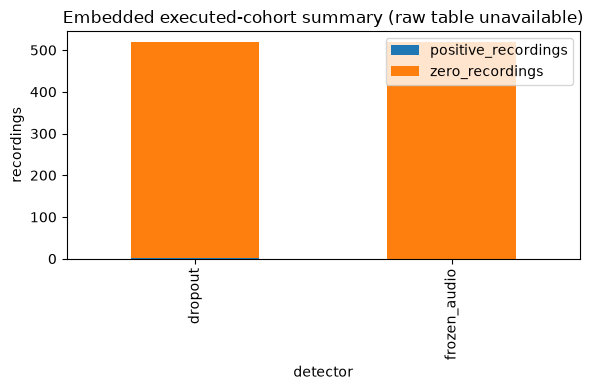

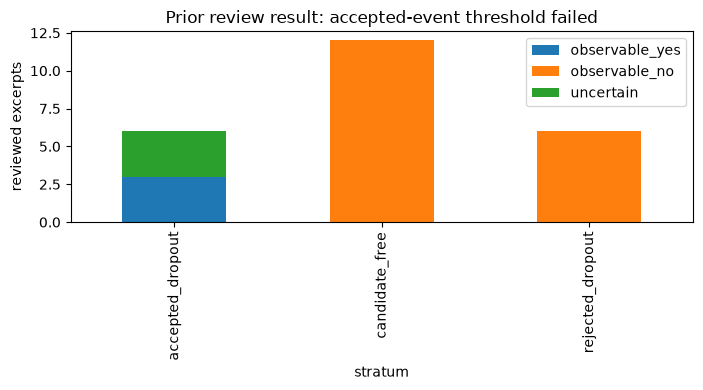

,panel,name,status,basis
0,A,construct response,GENERATED,synthetic dose grid
1,B,discriminant specificity,GENERATED,matched synthetic controls
2,C,transformation contract,GENERATED,gain and polarity; codec/native comparison rem...
3,D,support and availability,GENERATED,minimum exposure and missing-versus-zero
4,E,parameter sensitivity,GENERATED,duplicate boundary threshold
5,F,empirical distribution,CONDITIONAL,summary only; raw MAIN outputs absent
6,G,signal-linked examples,PENDING,native media/gallery bundle absent
7,H,reliability and redundancy,CONDITIONAL,reconstructability/same-ledger audit; particip...
8,I,blinded event verification,FAIL,3/6 accepted dropout excerpts observable yes; ...
9,J,quality-aware ML handoff,GENERATED,schema audit only; no diagnostic analysis


In [8]:
panel_f=pd.DataFrame([["dropout",2,517],["frozen_audio",0,519]],columns=["detector","positive_recordings","zero_recordings"])
panel_f.to_csv(OUTPUT/"tables"/"qtemp_v100_panel-F_empirical-summary.source.csv",index=False)
ax=panel_f.set_index("detector")[["positive_recordings","zero_recordings"]].plot.bar(stacked=True,figsize=(6,4)); ax.set(ylabel="recordings",title="Embedded executed-cohort summary (raw table unavailable)"); plt.tight_layout(); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-F_empirical-summary.png",dpi=300); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-F_empirical-summary.svg"); plt.show()

panel_h=pd.DataFrame([
 ["dropout", "duration fraction", "event rate", "same accepted ledger; complementary burden/frequency, not independent"],
 ["frozen_audio", "duration fraction", "event rate", "same accepted ledger; zero cohort variation in prior run"],
],columns=["event_type","view_1","view_2","interpretation"])
panel_h.to_csv(OUTPUT/"tables"/"qtemp_v100_panel-H_reliability-redundancy.source.csv",index=False)

panel_i=pd.DataFrame([
 ["accepted_dropout",6,3,0,3,0.50,">=0.80",False],
 ["candidate_free",12,0,12,0,0.00,"<=0.10",True],
 ["rejected_dropout",6,0,6,0,0.00,"<=0.20",True],
],columns=["stratum","reviewed","observable_yes","observable_no","uncertain","yes_fraction","required","passed"])
panel_i.to_csv(OUTPUT/"tables"/"qtemp_v100_panel-I_blinded-event-verification.source.csv",index=False)
ax=panel_i.set_index("stratum")[["observable_yes","observable_no","uncertain"]].plot.bar(stacked=True,figsize=(7,4)); ax.set(ylabel="reviewed excerpts",title="Prior review result: accepted-event threshold failed"); plt.tight_layout(); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-I_blinded-event-verification.png",dpi=300); ax.figure.savefig(OUTPUT/"figures"/"qtemp_v100_panel-I_blinded-event-verification.svg"); plt.show()

panel_j=pd.DataFrame([
 ["feature_value","float","NaN when unavailable"],
 ["feature_status","category","measured_zero / measured_positive / unavailable reason"],
 ["eligible_duration_sec","float","exposure and precision context"],
 ["accepted_event_count","integer","same-ledger count"],
 ["rate_ci95_low/high_per_min","float","exact Poisson uncertainty"],
 ["measurement_version","string","feature identity"],
],columns=["field","dtype","use"])
panel_j.to_csv(OUTPUT/"tables"/"qtemp_v100_panel-J_ml-handoff.source.csv",index=False)

gallery=pd.DataFrame([
 ["A","construct response","GENERATED","synthetic dose grid"],
 ["B","discriminant specificity","GENERATED","matched synthetic controls"],
 ["C","transformation contract","GENERATED","gain and polarity; codec/native comparison remains cohort-output dependent"],
 ["D","support and availability","GENERATED","minimum exposure and missing-versus-zero"],
 ["E","parameter sensitivity","GENERATED","duplicate boundary threshold"],
 ["F","empirical distribution","CONDITIONAL","summary only; raw MAIN outputs absent"],
 ["G","signal-linked examples","PENDING","native media/gallery bundle absent"],
 ["H","reliability and redundancy","CONDITIONAL","reconstructability/same-ledger audit; participant repeats require raw outputs"],
 ["I","blinded event verification","FAIL","3/6 accepted dropout excerpts observable yes; required >=0.80"],
 ["J","quality-aware ML handoff","GENERATED","schema audit only; no diagnostic analysis"],
],columns=["panel","name","status","basis"])
gallery.to_csv(OUTPUT/"validation"/"qtemp_v100_gallery_index.csv",index=False)
gallery


## 8. Master checklist and ten-domain dashboard


In [9]:
checklist=pd.DataFrame([
 ["C1","Construct","PASS","observable decoded-stream manifestations; no causal inference"],
 ["C4","Construct","PASS","splice dropped; QDIST/QADD/QGAIN boundaries explicit"],
 ["P1","Provenance","PASS","native decoded channels before transformations"],
 ["E1","Estimator","PASS","four registry rows with equation/unit/orientation/domain"],
 ["E5","Estimator","PASS","exact event-ledger reconstruction"],
 ["I2","Implementation","PASS","unavailable distinct from measured zero"],
 ["T1","Transformation","PASS","gain/polarity contract preflight"],
 ["T3","Transformation","PASS","native sample-rate dose grid"],
 ["T4","Transformation","CONDITIONAL","prior codec characterization exists; raw evidence bundle absent"],
 ["D2","Dose response","PASS","dropout and supported-lag repetition grids"],
 ["X3","Discriminant","CONDITIONAL","synthetic periodic controls pass; ALS dysarthric/real sustained-phonation negatives not supplied"],
 ["S3","Support","PASS","40-ms truth scope uses 37.5-ms evidence threshold due 2.5-ms frame/hop/native-rounding tolerance"],
 ["Plaus1","Empirical","CONDITIONAL","519-recording summary embedded; raw feature table absent"],
 ["R3","Reliability","PENDING","participant-level repeat data absent"],
 ["V2","Event verification","FAIL","accepted-event review threshold 0.50 < 0.80"],
 ["V3","Event verification","FAIL","G9 not passed"],
 ["F1","Figures","CONDITIONAL","G pending; F/H partial"],
 ["G10","Freeze","PENDING","four candidates retained pending G9; splice dropped"],
 ["G11","Freeze","PENDING","publication freeze prohibited"],
 ["G12","Freeze","PENDING","manuscript census must change from five to four if final decision holds"],
],columns=["id","domain","status","evidence_notes"])
checklist.to_csv(OUTPUT/"validation"/"QTEMP_Master_Validation_Checklist_v1_0.csv",index=False)
dashboard=checklist.groupby(["domain","status"]).size().unstack(fill_value=0).reset_index()
dashboard.to_csv(OUTPUT/"validation"/"QTEMP_Ten_Domain_Dashboard_v1_0.csv",index=False)
checklist


,id,domain,status,evidence_notes
0,C1,Construct,PASS,observable decoded-stream manifestations; no c...
1,C4,Construct,PASS,splice dropped; QDIST/QADD/QGAIN boundaries ex...
2,P1,Provenance,PASS,native decoded channels before transformations
3,E1,Estimator,PASS,four registry rows with equation/unit/orientat...
4,E5,Estimator,PASS,exact event-ledger reconstruction
5,I2,Implementation,PASS,unavailable distinct from measured zero
6,T1,Transformation,PASS,gain/polarity contract preflight
7,T3,Transformation,PASS,native sample-rate dose grid
8,T4,Transformation,CONDITIONAL,prior codec characterization exists; raw evide...
9,D2,Dose response,PASS,dropout and supported-lag repetition grids


## 9. Gates, completion requirements, and freeze refusal


In [10]:
gates=pd.DataFrame([
 ["G1","PASS","contract/provenance and four-feature candidate schema"],
 ["G2","PASS","63 relevant tests and exact reconstruction"],
 ["G3","CONDITIONAL","preflight transformations pass; raw prior signal-chain artifacts absent"],
 ["G4","PASS","synthetic and prior held-out evidence for retained detector scopes"],
 ["G5","CONDITIONAL","synthetic controls pass; real phenotype hard negatives still required"],
 ["G6","PASS","support/status and parameter boundary characterized"],
 ["G7","CONDITIONAL","executed summary present; raw MAIN outputs absent"],
 ["G8","CONDITIONAL","reconstructability passes; participant repeat audit not reproducible here"],
 ["G9","FAIL","accepted dropout observable-yes fraction 3/6 = 0.50; required >=0.80"],
 ["G10","BLOCKED","no publication freeze while G9 fails/pends"],
],columns=["gate","state","evidence"])
gates.to_csv(OUTPUT/"validation"/"QTEMP_Gate_Summary_v1_0.csv",index=False)
assert gates.set_index("gate").loc["G9","state"] != "PASS"
assert gates.set_index("gate").loc["G10","state"] == "BLOCKED"
if PUBLICATION_FREEZE:
    raise RuntimeError("Refusing QTEMP publication freeze: genuine blinded G9 has not passed")
gates


,gate,state,evidence
0,G1,PASS,contract/provenance and four-feature candidate...
1,G2,PASS,63 relevant tests and exact reconstruction
2,G3,CONDITIONAL,preflight transformations pass; raw prior sign...
3,G4,PASS,synthetic and prior held-out evidence for reta...
4,G5,CONDITIONAL,synthetic controls pass; real phenotype hard n...
5,G6,PASS,support/status and parameter boundary characte...
6,G7,CONDITIONAL,executed summary present; raw MAIN outputs absent
7,G8,CONDITIONAL,reconstructability passes; participant repeat ...
8,G9,FAIL,accepted dropout observable-yes fraction 3/6 =...
9,G10,BLOCKED,no publication freeze while G9 fails/pends


### Scientifically required completion sequence

1. Supply the frozen MAIN output tables, event ledgers, native review audio, and gallery figures matching the executed notebook hashes.
2. Re-run the reviewed four-feature candidate on all 519 recordings; verify exact agreement or explain every discrepancy from v0.3.1 reconstruction.
3. Inspect all accepted dropout events, all accepted frozen-audio events (if any), and fixed hard-negative/candidate-free strata blind to detector state and participant identity.
4. Because the prior accepted-event result was 3/6 observable yes (0.50), do not merely relabel uncertain cases. Diagnose failure modes, revise only using development material, then evaluate on a newly held-out blinded set.
5. Regenerate complete Panels F–I with participant-aware source data and artifact sidecars.
6. Only after G1–G9 pass may G10 create an immutable `qtemp-v1.0.0` publication freeze.
